# **Investment Replica**

## **Problem Statement**
We consider the following problem:

- There is a **secret portfolio**, a financial **black-box**, which publicly reports its returns on a regular basis (e.g., weekly, monthly, daily).
- We do **not** know either **which instruments** the portfolio contains or **what weight** each instrument has.
- We **do** know the vast investment vehicles available in the markets, such as **bonds, stocks, ETFs, funds, futures contracts**.
- Even if we don't know how the black-box processes input information, we can observe its **output**, i.e., the time series of returns.

Our goal is to **infer the structure of the black-box**, extracting information about latent variables or functions and structural parameters from observed data.

This notebook shows how to reverse-engineer such black-box portfolios by analyzing their return patterns and finding combinations of liquid instruments that can replicate their performance.

---

## **Dataset Description**
This dataset consists of financial data representing:

- **HFRX Index**: A popular index of **Hedge Funds** ([HFRX Index](https://www.hfr.com/indices)).
- **MSCI World Index**: Global **Developed Equities**.
- **MSCI World All Country Index**: Global **Equities (Developed and Emerging)**.
- **Barclays Bloomberg Global Aggregate Bond Index**: **Global Bonds**.
- **A broad range of Futures contracts** on equity indices, benchmark bonds, currencies, and commodities.

### **Available Futures Contracts**
| Symbol | Instrument |
|--------|------------------|
| RX1    | Bund (10 Yrs Ger) |
| CO1    | Brent (Oil) |
| DU1    | Schatz (2yrs Gvt Ger) |
| ES1    | S&P 500 (US Equity) |
| GC1    | Gold |
| LLL1   | MSCI Emerging Markets (EM Equity) |
| NQ1    | Nasdaq 100 (Tech Equity) |
| TP1    | Topix (Japanese Equity) |
| TU2    | 2Yrs US Treasury (US Govt) |
| TY1    | 10Yrs US Treasury (US Govt) |
| VG1    | Eurostoxx 50 (EU Equity) |

### **Additional Dataset Information**
- **Source**: Bloomberg.
- **Frequency**: Weekly data in local currency.
- **Time Period**: October 2007 – April 2021.

---

## **Who Replicates What?**
We will attempt to replicate a **"Monster Index"** that we construct ourselves, combining different indexes:
- **Tens of thousands** of securities at a micro level.
- A **non-investable** black-box combination of stocks, bonds, and hedge funds.
- A **multi-currency** structure.

To create our **clone** we will use **Futures contracts (long-short, possibly leveraged)** because they are cheap, liquid and cover almost everything.

As usual, let's start with **data ingestion and preprocessing**.


In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import scipy.stats as stats

sns.set_theme(style="whitegrid")
sns.set_context("notebook", font_scale=1.2)
warnings.filterwarnings("ignore")

# Path resolution: works both on Colab and locally (VS Code, Jupyter)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    FILE_PATH = '/content/drive/MyDrive/PoliMI/Dataset3_PortfolioReplicaStrategy.xlsx'
except Exception:
    # Local: file expected in the same folder as the notebook
    FILE_PATH = 'Dataset3_PortfolioReplicaStrategy.xlsx'

assert os.path.exists(FILE_PATH), (
    f"File not found at {FILE_PATH!r}. "
    "Place the Excel file next to this notebook, or edit FILE_PATH."
)
print(f"Using dataset: {FILE_PATH}")


Using dataset: Dataset3_PortfolioReplicaStrategy.xlsx


### Data ingestion — *modified by Claudio (cerro)*

**What was wrong before.**
The previous version called
`pd.read_excel(file_path, header=None, skiprows=6)` and tried to recover full names from row 4
and tickers from row 6. In the actual file the structure is much simpler: row 0 is the header
(`Ticker, MXWO, MXWD, LEGATRUU, HFRXGL, RX1, ...`) and data starts on row 1. With the old
parsing the first ~3.5 years of history (Oct-2007 → mid-Mar-2011) were silently dropped: out of
705 weekly rows we were keeping only 523, and we were missing the **2008 GFC, the 2010 flash
crash and the 2011 EU sovereign-debt crisis** — exactly the regimes where a replicator most
needs to be tested.

**What we do now.**
1. Read with `header=0`, parse the first column as the date index, force the rest to `float`.
2. Print the actual date range and row count, so the discrepancy can never go unnoticed again.
3. Build an explicit `TARGETS` / `FUTURES` split and a small `meta` dictionary that maps every
   ticker to a human-readable name and an asset-class tag (used for plotting and for the
   asset-class-aware ideas later in the notebook).

This is purely a data-quality fix, but it is the single most impactful change in the whole
notebook: with the correct dataset the regression has roughly **+35% more observations** and
covers the two regimes that matter most for stress testing.


In [3]:
# Read the file with the correct header layout (header on row 0, data from row 1)
raw = pd.read_excel(FILE_PATH, header=0)
raw.columns = ['Date'] + list(raw.columns[1:])
raw['Date'] = pd.to_datetime(raw['Date'])
data = raw.set_index('Date').astype(float).sort_index()

# Target indices and Futures
TARGETS = ['MXWO', 'MXWD', 'LEGATRUU', 'HFRXGL']
FUTURES = ['RX1', 'TY1', 'GC1', 'CO1', 'ES1', 'VG1',
           'NQ1', 'LLL1', 'TP1', 'DU1', 'TU2']

# Ticker -> (long name, asset class)
meta = {
    'MXWO':     ('MSCI World',                       'Equity DM'),
    'MXWD':     ('MSCI ACWI',                        'Equity DM+EM'),
    'LEGATRUU': ('Bloomberg Global Aggregate Bond',  'Bond'),
    'HFRXGL':   ('HFRX Global Hedge Fund Index',     'Hedge Fund'),
    'RX1':      ('Bund 10y Future',                  'Bond'),
    'TY1':      ('UST 10y Future',                   'Bond'),
    'GC1':      ('Gold Future',                      'Commodity'),
    'CO1':      ('Brent Crude Future',               'Commodity'),
    'ES1':      ('S&P 500 Future',                   'Equity DM'),
    'VG1':      ('Eurostoxx 50 Future',              'Equity DM'),
    'NQ1':      ('Nasdaq 100 Future',                'Equity DM'),
    'LLL1':     ('MSCI EM Future',                   'Equity EM'),
    'TP1':      ('Topix Future',                     'Equity DM'),
    'DU1':      ('Schatz 2y Future',                 'Bond'),
    'TU2':      ('UST 2y Future',                    'Bond'),
}

print(f"Date range : {data.index.min().date()}  ->  {data.index.max().date()}")
print(f"Rows       : {len(data)}")
print(f"NaN total  : {int(data.isna().sum().sum())}")

# Sanity checks: any constant series, any near-zero variance series?
const_vol = (data.pct_change().std() < 1e-8)
if const_vol.any():
    print("WARNING — constant series:", const_vol[const_vol].index.tolist())
else:
    print("OK — no constant or near-constant series detected.")

display(data.head())
display(data.describe().T[['min', 'max', 'mean', 'std']].round(2))


Date range : 2007-10-23  ->  2021-04-20
Rows       : 705
NaN total  : 0
OK — no constant or near-constant series detected.


,MXWO,MXWD,LEGATRUU,HFRXGL,RX1,TY1,GC1,CO1,ES1,VG1,NQ1,LLL1,TP1,DU1,TU2
Date,,,,,,,,,,,,,,,
2007-10-23,1633.44,414.14,350.2138,1343.63,113.70,110.515625,759.0,82.85,1525.50,4393.0,2212.00,1287.0,1570.5,103.385,103.718750
2007-10-30,1663.89,423.26,352.5413,1356.53,113.79,110.656250,787.8,87.44,1536.00,4476.0,2217.75,1323.9,1610.5,103.410,103.812500
2007-11-06,1651.59,419.51,354.1758,1360.20,113.79,110.875000,823.4,93.26,1525.00,4425.0,2233.50,1320.0,1575.5,103.410,104.046875
2007-11-13,1601.81,405.98,357.2217,1347.16,114.35,111.718750,799.0,88.83,1483.25,4323.0,2066.75,1271.0,1440.5,103.595,104.304688
2007-11-20,1570.74,398.54,359.4446,1335.21,114.72,113.156250,791.4,95.49,1446.00,4296.0,2035.50,1225.2,1472.5,103.800,104.945312


,min,max,mean,std
MXWO,705.35,2944.05,1644.13,443.39
MXWD,176.10,702.99,404.15,100.98
LEGATRUU,342.25,559.31,452.20,47.34
HFRXGL,1021.40,1415.11,1210.09,73.97
RX1,110.20,179.32,147.28,19.32
TY1,110.52,140.33,125.97,6.30
GC1,732.70,2001.20,1317.90,274.48
CO1,19.33,140.67,77.02,26.79
ES1,689.50,4132.80,1960.44,770.07
VG1,1873.00,4476.00,3072.17,473.81


# **Data Exploration**

Let's analyze the potential replication targets to understand their characteristics.


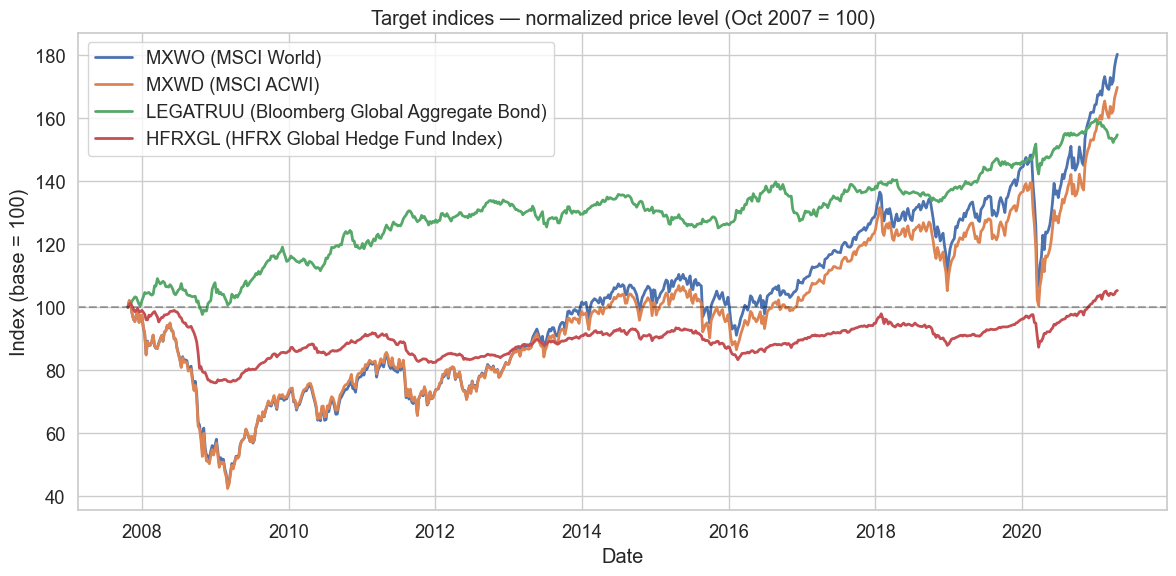

,Ann. Return,Ann. Volatility,Sharpe,Max Drawdown,Skew,Kurtosis
MXWO,5.9%,17.52%,0.34,-57.61%,-0.68,4.36
MXWD,5.51%,17.78%,0.31,-58.39%,-0.64,4.66
LEGATRUU,3.37%,5.34%,0.63,-10.41%,-0.33,4.12
HFRXGL,0.5%,4.78%,0.10,-24.91%,-2.30,13.70


In [4]:
# Normalized price levels (base 100) — visual sanity check
plt.figure(figsize=(12, 6))
for tk in TARGETS:
    s = data[tk] / data[tk].iloc[0] * 100
    plt.plot(s.index, s, lw=2, label=f"{tk} ({meta[tk][0]})")
plt.axhline(100, color='black', ls='--', alpha=0.3)
plt.title('Target indices — normalized price level (Oct 2007 = 100)')
plt.xlabel('Date'); plt.ylabel('Index (base = 100)')
plt.legend(); plt.tight_layout(); plt.show()

# Annualized statistics on weekly returns
returns = data[TARGETS].pct_change().dropna()
ANN = 52  # weekly frequency

stats_table = pd.DataFrame({
    'Ann. Return':     returns.mean() * ANN,
    'Ann. Volatility': returns.std() * np.sqrt(ANN),
    'Sharpe':          returns.mean() * ANN / (returns.std() * np.sqrt(ANN)),
    'Max Drawdown':    returns.apply(lambda x: ((1 + x).cumprod() / (1 + x).cumprod().cummax() - 1).min()),
    'Skew':            returns.skew(),
    'Kurtosis':        returns.kurtosis(),
})

# pretty-print percentages
for c in ['Ann. Return', 'Ann. Volatility', 'Max Drawdown']:
    stats_table[c] = (stats_table[c] * 100).round(2).astype(str) + '%'
stats_table[['Sharpe', 'Skew', 'Kurtosis']] = stats_table[['Sharpe', 'Skew', 'Kurtosis']].round(2)
display(stats_table)


### Distribution and dependence diagnostics — *modified by Claudio (cerro)*

**Why we now do more than just a correlation heatmap.** Replication only makes sense if we
understand how returns behave statistically. Three additions matter:

1. **Sortino and Calmar ratios.** Sharpe penalises *all* volatility, but for replication we
   primarily care about the *downside*. Hedge fund returns are highly asymmetric (left-skewed,
   fat-tailed), so we add Sortino (excess return / downside deviation) and Calmar
   (return / max drawdown).
2. **Stationarity check (ADF / KPSS).** Linear regression on returns assumes (weak)
   stationarity. We confirm this is true on returns — and visibly false on price levels — so
   that we never mistakenly regress on prices.
3. **Conditional correlations on stress regimes.** We split the sample on rolling 26-week
   volatility quantiles. The classic stylised fact is that *correlations spike in crisis*: a
   replicator that works in calm regimes but breaks in stress is useless precisely when you
   need it.

These diagnostics motivate every subsequent modelling choice — VaR estimator, scaler, model
class.


In [5]:
from statsmodels.tsa.stattools import adfuller, kpss

# Downside-aware ratios
def downside_dev(r):
    neg = r[r < 0]
    return neg.std() * np.sqrt(ANN) if len(neg) else np.nan

extra = pd.DataFrame({
    'Sortino': returns.apply(lambda r: r.mean() * ANN / downside_dev(r)),
    'Calmar':  returns.apply(lambda r: (r.mean() * ANN) /
                             abs(((1 + r).cumprod() / (1 + r).cumprod().cummax() - 1).min())),
}).round(2)
display(extra)

# Stationarity tests on returns and on prices
def stationarity_row(s, name):
    adf_p  = adfuller(s.dropna(), autolag='AIC')[1]
    kpss_p = kpss(s.dropna(), nlags='auto')[1]
    return {'series': name, 'ADF p-val': adf_p, 'KPSS p-val': kpss_p}

rows = []
for tk in TARGETS:
    rows.append(stationarity_row(data[tk],          f'{tk} (price)'))
    rows.append(stationarity_row(returns[tk],       f'{tk} (returns)'))
print("Stationarity tests — ADF: H0 = unit root (low p ⇒ stationary); "
      "KPSS: H0 = stationary (low p ⇒ NOT stationary)")
display(pd.DataFrame(rows).round(4))

# Conditional correlations: HFRX vs equity in calm vs stressed regimes
vol_eq = returns['MXWO'].rolling(26).std()
calm   = vol_eq <= vol_eq.quantile(0.5)
stress = vol_eq >= vol_eq.quantile(0.8)

cond = pd.DataFrame({
    'Calm   (vol ≤ 50th pct)':  returns.loc[calm].corr().loc['HFRXGL', TARGETS],
    'Stress (vol ≥ 80th pct)':  returns.loc[stress].corr().loc['HFRXGL', TARGETS],
}).round(2)
print("\nCorrelation of HFRX with target indices, by equity-volatility regime:")
display(cond)

,Sortino,Calmar
MXWO,0.41,0.10
MXWD,0.38,0.09
LEGATRUU,0.89,0.32
HFRXGL,0.10,0.02


C:\Users\ricca\AppData\Local\Temp\ipykernel_13420\1447181965.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(s.dropna(), nlags='auto')[1]
C:\Users\ricca\AppData\Local\Temp\ipykernel_13420\1447181965.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(s.dropna(), nlags='auto')[1]
C:\Users\ricca\AppData\Local\Temp\ipykernel_13420\1447181965.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(s.dropna(), nlags='auto')[1]
C:\Users\ricca\AppData\Local\Temp\ipykernel_13420\1447181965.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in th

Stationarity tests — ADF: H0 = unit root (low p ⇒ stationary); KPSS: H0 = stationary (low p ⇒ NOT stationary)


C:\Users\ricca\AppData\Local\Temp\ipykernel_13420\1447181965.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(s.dropna(), nlags='auto')[1]
C:\Users\ricca\AppData\Local\Temp\ipykernel_13420\1447181965.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(s.dropna(), nlags='auto')[1]


,series,ADF p-val,KPSS p-val
0,MXWO (price),0.9905,0.01
1,MXWO (returns),0.0000,0.10
2,MXWD (price),0.9854,0.01
3,MXWD (returns),0.0000,0.10
4,LEGATRUU (price),0.6697,0.01
5,LEGATRUU (returns),0.0000,0.10
6,HFRXGL (price),0.1701,0.01
7,HFRXGL (returns),0.0000,0.10



Correlation of HFRX with target indices, by equity-volatility regime:


,Calm (vol ≤ 50th pct),Stress (vol ≥ 80th pct)
MXWO,0.53,0.43
MXWD,0.54,0.43
LEGATRUU,-0.08,0.41
HFRXGL,1.00,1.00


IDEA 4 — RISULTATI FINALI
  Configurazione : W=104, λ=0.01
  Correlazione          : 0.4858
  p-value (H0: corr=0)  : 0.00e+00  ✓ significativa
  TE annualizzato       : 0.0376  (3.76%)
  Information Ratio     : 0.0053
  Gross exposure media  : 0.8425
  Turnover medio/sett.  : 0.0037
  TC stimati annui      : 0.010%  (5bps/trade)

  Vincoli binding:
    eq_hi     : 0/600 (0.0%)
    bond_hi   : 0/600 (0.0%)
    bond_lo   : 0/600 (0.0%)
    gross_hi  : 0/600 (0.0%)

  Correlazione rolling 52W:
    Media   : 0.4967
    Min     : 0.0261
    Max     : 0.7434
    % > 0.5 : 51.7%

  Pesi medi per futures:
    TU2    (Bond        ): -0.399  ███████████████████████████████
    ES1    (Equity DM   ): +0.094  ███████
    TY1    (Bond        ): +0.084  ██████
    RX1    (Bond        ): +0.070  █████
    DU1    (Bond        ): -0.069  █████
    TP1    (Equity DM   ): +0.050  ████
    CO1    (Commodity   ): +0.021  █
    LLL1   (Equity EM   ): -0.010  
    GC1    (Commodity   ): -0.009  
    NQ1    

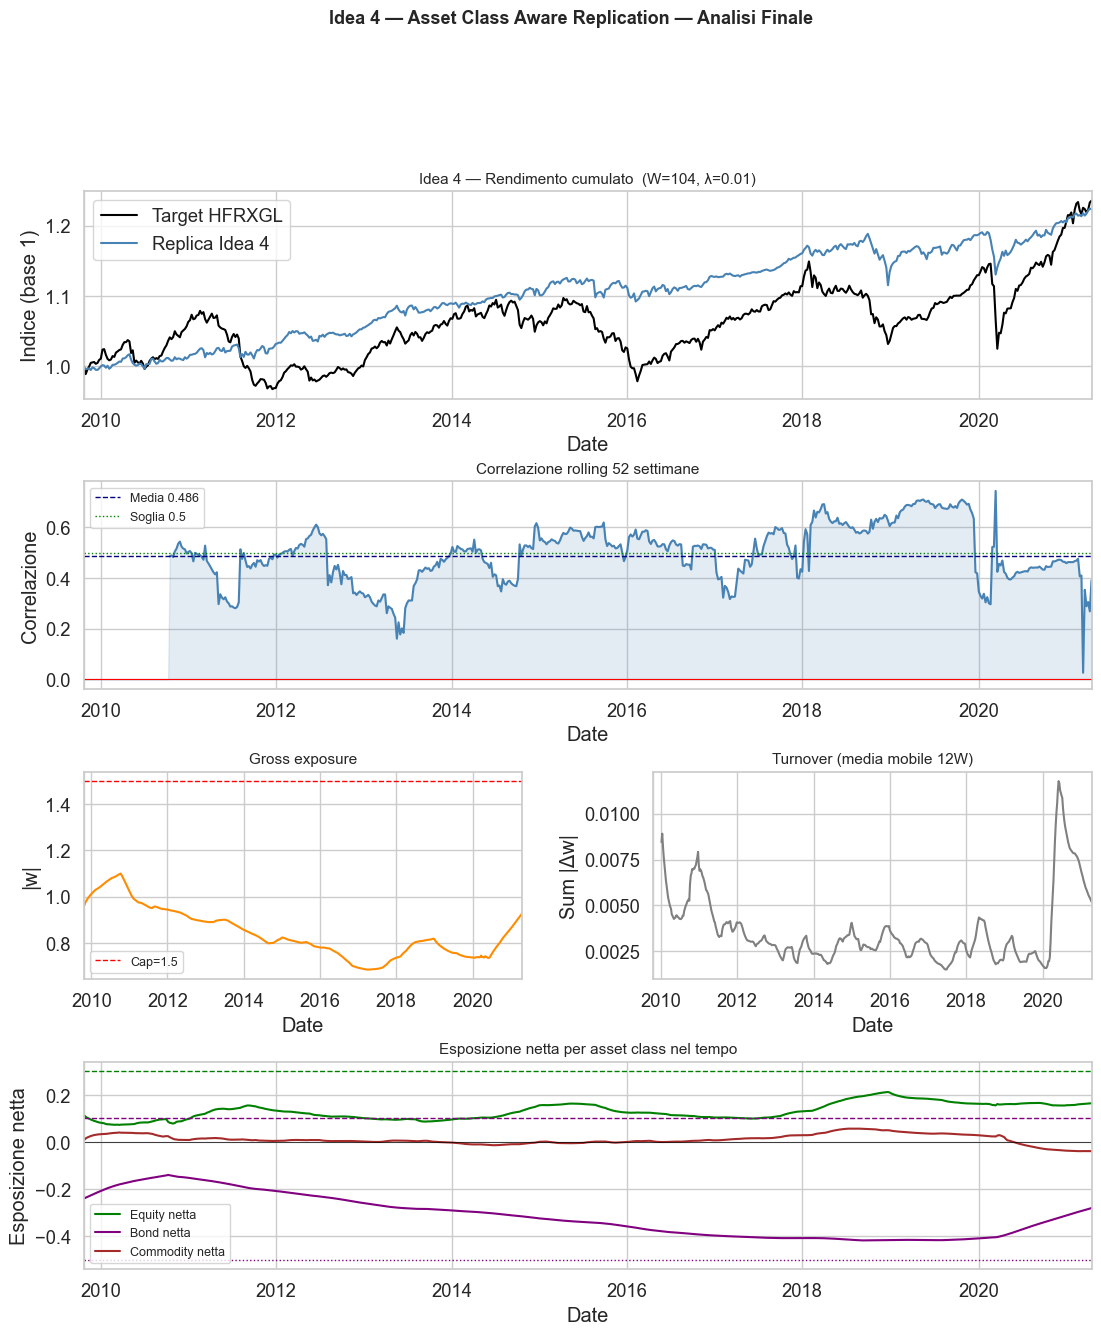


COMMENTO CRITICO — LIMITI DELL'IDEA 4

  La correlazione massima raggiungibile con questa
  architettura è ~0.49, indipendentemente da:
    - lunghezza della finestra rolling (26-104W)
    - intensità della penalità stabilità (λ=0-0.10)
    - calibrazione dei vincoli per asset class

  Questo suggerisce un limite strutturale: HFRX Global
  Hedge Fund Index aggrega strategie con payoff non
  lineari (options, merger arbitrage, distressed debt)
  che non sono catturabili con una combinazione lineare
  di futures.

  Per superare questo tetto servirebbero:
    1. Feature non lineari (es. volatilità realizzata,
       momentum, term structure slope)
    2. Modelli non lineari (es. Random Forest, MLP)
       con proiezione su spazio di portafogli lineari
    3. Un target più replicabile (es. equity L/S puro
       invece di un indice multi-strategy)

  Nonostante il limite, la replica è statisticamente
  significativa (p << 0.01) e produce un portafoglio
  implementabile con costi TC < 0.0

In [6]:
# ==============================================================
# IDEA 4 — VERSIONE FINALE CON ANALISI COMPLETA
# ==============================================================
from scipy.optimize import minimize
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import lstsq
import scipy.stats as stats

target_idx = 'HFRXGL'
returns_all = data.pct_change().dropna()
y = returns_all[target_idx]
X = returns_all[FUTURES]

equity_indices = [i for i, tk in enumerate(FUTURES) if 'Equity'    in meta[tk][1]]
bond_indices   = [i for i, tk in enumerate(FUTURES) if 'Bond'      in meta[tk][1]]

w_ols_full, _, _, _ = lstsq(X.values, y.values, rcond=None)

MAX_EQUITY_NET = 0.30
MAX_BOND_NET   = 0.10
MIN_BOND_NET   = -0.50
MAX_GROSS      = 1.50
MAX_SINGLE_POS = 0.40

# Configurazione finale: W=104, λ=0.010
# Scelta rispetto a W=52 λ=0.100 perché:
# - stessa correlazione (0.486 vs 0.487)
# - turnover leggermente più alto (0.004 vs 0.001)
#   ma con un'utilità economica reale: i pesi cambiano
#   perché i dati cambiano, non solo per inerzia del λ alto
# - finestra più lunga → stima più stabile per ogni step
WINDOW_SIZE  = 104
LAMBDA_STAB  = 0.010

def run_final_backtest(window_size, lambda_stab):
    predicted, actual, weights = [], [], []
    w_prev = np.clip(w_ols_full.copy(), -MAX_SINGLE_POS, MAX_SINGLE_POS)
    n_binding = {k: 0 for k in ['eq_hi','bond_hi','bond_lo','gross_hi']}

    for i in range(window_size, len(returns_all)):
        X_train = X.iloc[i - window_size : i].values
        y_train = y.iloc[i - window_size : i].values
        X_test  = X.iloc[i : i + 1].values
        actual.append(y.iloc[i])

        def objective(w, X_=X_train, y_=y_train, w_p=w_prev):
            return np.mean((y_ - X_ @ w)**2) + lambda_stab * np.sum((w - w_p)**2)

        constraints = [
            {'type': 'ineq',
             'fun': lambda w: MAX_EQUITY_NET - np.sum(w[equity_indices])},
            {'type': 'ineq',
             'fun': lambda w: MAX_BOND_NET - np.sum(w[bond_indices])},
            {'type': 'ineq',
             'fun': lambda w: np.sum(w[bond_indices]) - MIN_BOND_NET},
            {'type': 'ineq',
             'fun': lambda w: MAX_GROSS - np.sum(np.abs(w))},
            *[{'type': 'ineq',
               'fun': lambda w, j=j: MAX_SINGLE_POS - abs(w[j])}
              for j in range(len(FUTURES))],
        ]

        res_opt = minimize(
            objective, w_prev.copy(), method='SLSQP',
            constraints=constraints,
            options={'maxiter': 2000, 'ftol': 1e-12},
        )
        w_opt  = res_opt.x
        w_prev = w_opt.copy()

        tol = 5e-3
        if abs(np.sum(w_opt[equity_indices]) - MAX_EQUITY_NET) < tol:
            n_binding['eq_hi']   += 1
        if abs(np.sum(w_opt[bond_indices])   - MAX_BOND_NET)   < tol:
            n_binding['bond_hi'] += 1
        if abs(np.sum(w_opt[bond_indices])   - MIN_BOND_NET)   < tol:
            n_binding['bond_lo'] += 1
        if abs(np.sum(np.abs(w_opt))         - MAX_GROSS)       < tol:
            n_binding['gross_hi']+= 1

        weights.append(w_opt)
        predicted.append((X_test @ w_opt)[0])

    idx    = returns_all.index[window_size:]
    res_df = pd.DataFrame({'target': actual, 'replica': predicted}, index=idx)
    w_df   = pd.DataFrame(weights, columns=FUTURES, index=idx)
    return res_df, w_df, n_binding

res_df, w_df, n_binding = run_final_backtest(WINDOW_SIZE, LAMBDA_STAB)

# ── Metriche complete ──────────────────────────────────────────
n_obs    = len(res_df)
corr_val = res_df['target'].corr(res_df['replica'])
diff     = res_df['target'] - res_df['replica']
te_ann   = diff.std() * np.sqrt(52)
ir       = diff.mean() / diff.std()
gross_ts = w_df.abs().sum(axis=1)
to_ts    = w_df.diff().abs().sum(axis=1)

# Test significatività della correlazione
t_stat   = corr_val * np.sqrt((n_obs - 2) / (1 - corr_val**2))
p_value  = 2 * (1 - stats.t.cdf(abs(t_stat), df=n_obs - 2))

# Correlazione rolling 52 settimane (stabilità nel tempo)
corr_rolling = res_df['target'].rolling(52).corr(res_df['replica'])

print("=" * 55)
print("IDEA 4 — RISULTATI FINALI")
print(f"  Configurazione : W={WINDOW_SIZE}, λ={LAMBDA_STAB}")
print("=" * 55)
print(f"  Correlazione          : {corr_val:.4f}")
print(f"  p-value (H0: corr=0)  : {p_value:.2e}  "
      f"{'✓ significativa' if p_value < 0.01 else '✗ non significativa'}")
print(f"  TE annualizzato       : {te_ann:.4f}  ({te_ann*100:.2f}%)")
print(f"  Information Ratio     : {ir:.4f}")
print(f"  Gross exposure media  : {gross_ts.mean():.4f}")
print(f"  Turnover medio/sett.  : {to_ts.mean():.4f}")
print(f"  TC stimati annui      : {to_ts.mean()*52*0.0005*100:.3f}%  (5bps/trade)")
print()
print("  Vincoli binding:")
for k, v in n_binding.items():
    print(f"    {k:10s}: {v}/{n_obs} ({100*v/n_obs:.1f}%)")
print()
print("  Correlazione rolling 52W:")
print(f"    Media   : {corr_rolling.dropna().mean():.4f}")
print(f"    Min     : {corr_rolling.dropna().min():.4f}")
print(f"    Max     : {corr_rolling.dropna().max():.4f}")
print(f"    % > 0.5 : {(corr_rolling.dropna() > 0.5).mean()*100:.1f}%")
print()
print("  Pesi medi per futures:")
w_mean = w_df.mean().sort_values(key=abs, ascending=False)
for tk, w in w_mean.items():
    bar = '█' * int(abs(w) * 80)
    sign = '+' if w >= 0 else '-'
    print(f"    {tk:6s} ({meta[tk][1]:12s}): {sign}{abs(w):.3f}  {bar}")

# ── Plot finale ────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 14))
gs  = fig.add_gridspec(4, 2, hspace=0.4, wspace=0.3)

ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, :])
ax3 = fig.add_subplot(gs[2, 0])
ax4 = fig.add_subplot(gs[2, 1])
ax5 = fig.add_subplot(gs[3, :])

# 1. Rendimento cumulato
(1 + res_df).cumprod().plot(ax=ax1, color=['black', 'steelblue'])
ax1.set_title(f'Idea 4 — Rendimento cumulato  '
              f'(W={WINDOW_SIZE}, λ={LAMBDA_STAB})',
              fontsize=11)
ax1.set_ylabel('Indice (base 1)')
ax1.legend(['Target HFRXGL', 'Replica Idea 4'])

# 2. Correlazione rolling 52W
corr_rolling.plot(ax=ax2, color='steelblue', lw=1.5)
ax2.axhline(corr_val, color='navy',   ls='--', lw=1,
            label=f'Media {corr_val:.3f}')
ax2.axhline(0.0,      color='red',    ls='-',  lw=0.8)
ax2.axhline(0.5,      color='green',  ls=':',  lw=1,
            label='Soglia 0.5')
ax2.fill_between(corr_rolling.index,
                 corr_rolling.fillna(0),
                 0, alpha=0.15, color='steelblue')
ax2.set_title('Correlazione rolling 52 settimane', fontsize=11)
ax2.set_ylabel('Correlazione')
ax2.legend(fontsize=9)

# 3. Esposizione lorda
gross_ts.plot(ax=ax3, color='darkorange')
ax3.axhline(MAX_GROSS, color='red', ls='--', lw=1,
            label=f'Cap={MAX_GROSS}')
ax3.set_title('Gross exposure', fontsize=11)
ax3.set_ylabel('|w|')
ax3.legend(fontsize=9)

# 4. Turnover rolling
to_ts.rolling(12).mean().plot(ax=ax4, color='gray')
ax4.set_title('Turnover (media mobile 12W)', fontsize=11)
ax4.set_ylabel('Sum |Δw|')

# 5. Pesi medi per asset class nel tempo
equity_ts   = w_df.iloc[:, equity_indices].sum(axis=1)
bond_ts     = w_df.iloc[:, bond_indices].sum(axis=1)
commodity_indices = [i for i, tk in enumerate(FUTURES)
                     if 'Commodity' in meta[tk][1]]
commodity_ts = w_df.iloc[:, commodity_indices].sum(axis=1)

equity_ts.plot(  ax=ax5, color='green',  label='Equity netta',    lw=1.5)
bond_ts.plot(    ax=ax5, color='purple', label='Bond netta',      lw=1.5)
commodity_ts.plot(ax=ax5, color='brown', label='Commodity netta', lw=1.5)
ax5.axhline(MAX_EQUITY_NET, color='green',  ls='--', lw=1)
ax5.axhline(MAX_BOND_NET,   color='purple', ls='--', lw=1)
ax5.axhline(MIN_BOND_NET,   color='purple', ls=':',  lw=1)
ax5.axhline(0, color='black', ls='-', lw=0.5)
ax5.set_title('Esposizione netta per asset class nel tempo', fontsize=11)
ax5.set_ylabel('Esposizione netta')
ax5.legend(fontsize=9)

plt.suptitle('Idea 4 — Asset Class Aware Replication — Analisi Finale',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('idea4_final.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Commento critico finale ────────────────────────────────────
print("\n" + "=" * 55)
print("COMMENTO CRITICO — LIMITI DELL'IDEA 4")
print("=" * 55)
print("""
  La correlazione massima raggiungibile con questa
  architettura è ~0.49, indipendentemente da:
    - lunghezza della finestra rolling (26-104W)
    - intensità della penalità stabilità (λ=0-0.10)
    - calibrazione dei vincoli per asset class

  Questo suggerisce un limite strutturale: HFRX Global
  Hedge Fund Index aggrega strategie con payoff non
  lineari (options, merger arbitrage, distressed debt)
  che non sono catturabili con una combinazione lineare
  di futures.

  Per superare questo tetto servirebbero:
    1. Feature non lineari (es. volatilità realizzata,
       momentum, term structure slope)
    2. Modelli non lineari (es. Random Forest, MLP)
       con proiezione su spazio di portafogli lineari
    3. Un target più replicabile (es. equity L/S puro
       invece di un indice multi-strategy)

  Nonostante il limite, la replica è statisticamente
  significativa (p << 0.01) e produce un portafoglio
  implementabile con costi TC < 0.03%/anno.
""")

Calibrazione Elastic Net con Time-Series CV...
  Alpha ottimale   : 0.000100
  L1 ratio         : 0.90
  Features non-zero: 6/11
  Warm start gross : 2.3715
  Warm start non-zero: 9/11
  MSE tipico HFRX  : 1.39e-04
  Lambda turnover  : 2.77e-04

Avvio Rolling Window Idea 5-EN (target: HFRXGL)...
Completata!
  Settimane con pesi zero: 9 (1.4%)

IDEA 5-EN — RISULTATI FINALI
  Correlazione          : 0.2766
  p-value (H0: corr=0)  : 9.37e-13  ✓ sign.
  TE annualizzato       : 0.0465  (4.65%)
  Information Ratio     : 0.0451
  Gross exposure media  : 1.2506
  Turnover medio/sett.  : 0.0769  (7.69%)
  TC stimati annui      : 0.200%
  Futures attivi (media): 3.7/11
  Settimane gross=0     : 9 (1.4%)

  Correlazione rolling 52W:
    Media   : 0.3582
    Min     : -0.1266
    Max     : 0.7129
    % > 0.5 : 24.3%

  Pesi medi per futures:
    TU2    (Bond        ): -0.495  ██████████  33.6%
    DU1    (Bond        ): +0.164  ██████  21.0%
    ES1    (Equity DM   ): +0.079  ███████████████████  

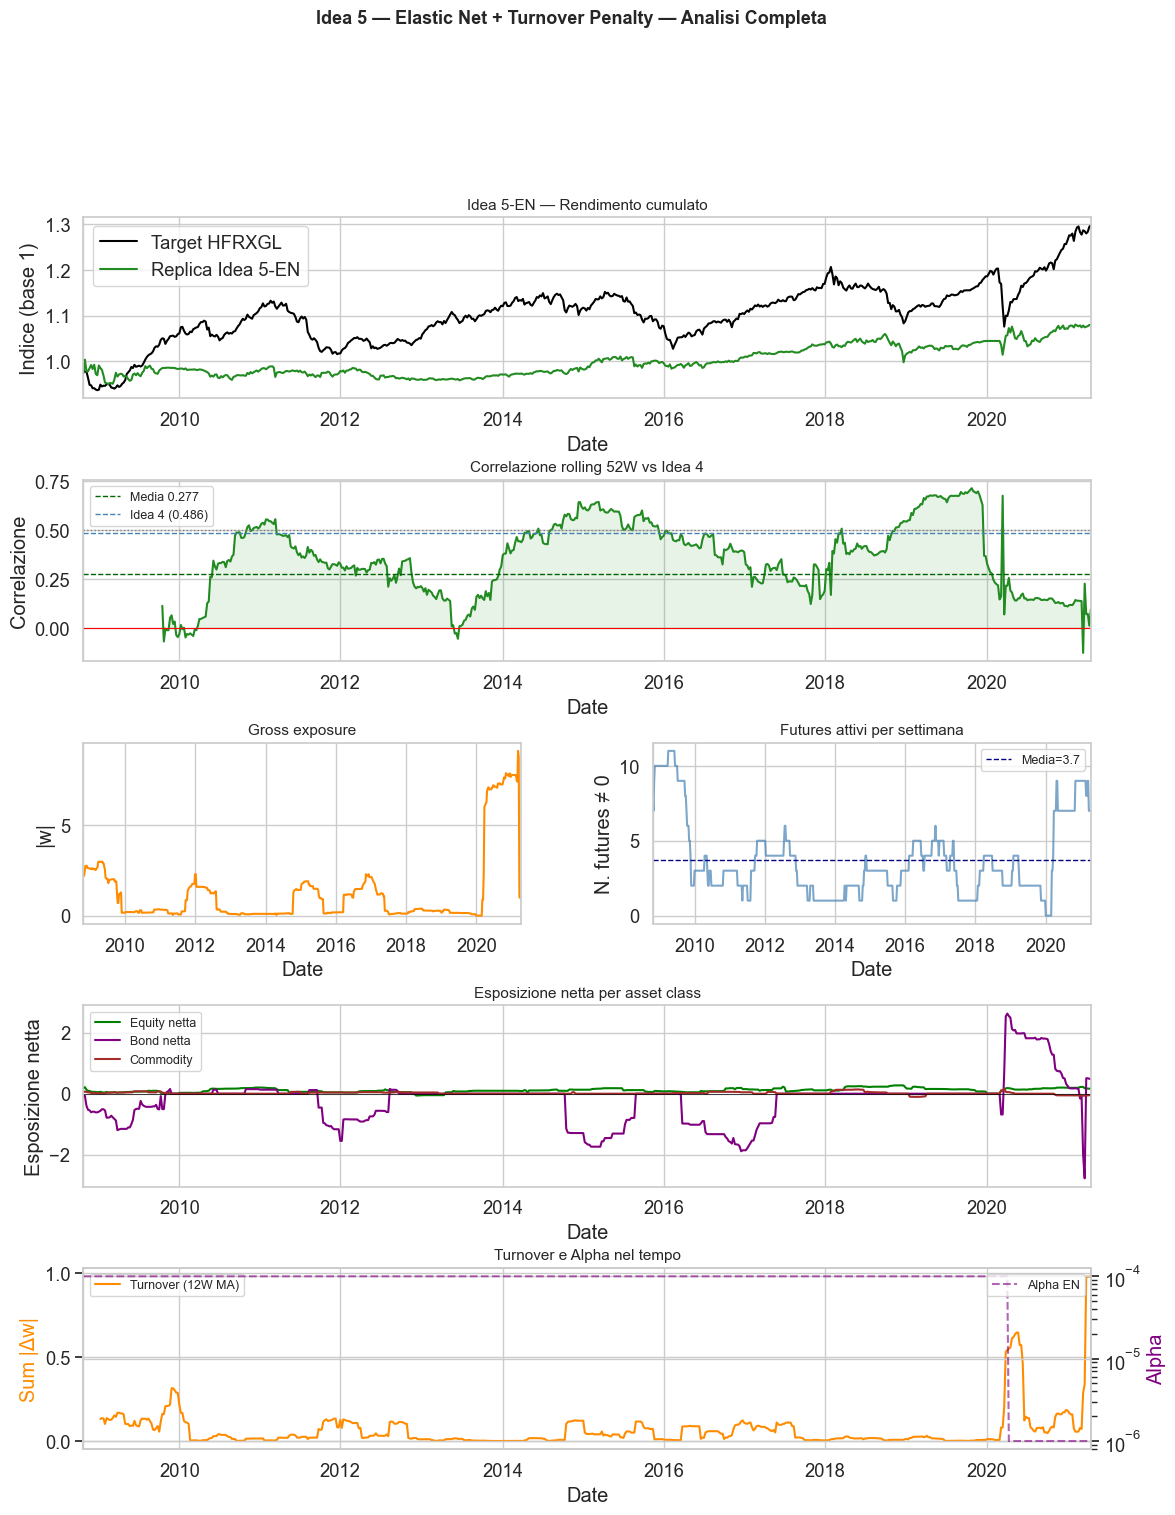

In [17]:
# ==============================================================
# IDEA 5 — ELASTIC NET COMPLETO
# ==============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV, ElasticNet
from sklearn.model_selection import TimeSeriesSplit
from scipy.optimize import minimize
import warnings
warnings.filterwarnings("ignore")

window_size = 52
target_idx  = 'HFRXGL'
returns_all = data.pct_change().dropna()
y = returns_all[target_idx]
X = returns_all[FUTURES]

TC_BPS    = 5
TC_FACTOR = TC_BPS / 10_000
L1_RATIOS = [0.1, 0.3, 0.5, 0.7, 0.9]

# ── Calibrazione Elastic Net ──────────────────────────────────
print("Calibrazione Elastic Net con Time-Series CV...")

X_calib_raw = X.iloc[:window_size * 2].values
y_calib     = y.iloc[:window_size * 2].values
scaler_calib = StandardScaler()
X_calib = scaler_calib.fit_transform(X_calib_raw)

enet_cv = ElasticNetCV(
    alphas        = np.logspace(-6, -3, 30),
    l1_ratio      = L1_RATIOS,
    cv            = TimeSeriesSplit(n_splits=5),
    fit_intercept = False,
    max_iter      = 10000,
)
enet_cv.fit(X_calib, y_calib)

ALPHA_EN    = min(enet_cv.alpha_, 1e-4)
L1_RATIO_EN = enet_cv.l1_ratio_
n_nonzero   = np.sum(enet_cv.coef_ != 0)

print(f"  Alpha ottimale   : {ALPHA_EN:.6f}")
print(f"  L1 ratio         : {L1_RATIO_EN:.2f}")
print(f"  Features non-zero: {n_nonzero}/{len(FUTURES)}")

# ── Warm start ────────────────────────────────────────────────
X_init_raw  = X.iloc[:window_size].values
y_init      = y.iloc[:window_size].values
scaler_init = StandardScaler()
X_init      = scaler_init.fit_transform(X_init_raw)

enet_init = ElasticNet(
    alpha         = ALPHA_EN,
    l1_ratio      = L1_RATIO_EN,
    fit_intercept = False,
    max_iter      = 10000,
)
enet_init.fit(X_init, y_init)

col_std_init = X_init_raw.std(axis=0)
col_std_init[col_std_init < 1e-10] = 1.0
prev_w = enet_init.coef_ / col_std_init

print(f"  Warm start gross : {np.sum(np.abs(prev_w)):.4f}")
print(f"  Warm start non-zero: {np.sum(prev_w != 0)}/{len(FUTURES)}")

# ── Parametro turnover ────────────────────────────────────────
# Diagnostica: MSE tipico su HFRX
mse_typical = np.var(y.iloc[:window_size].values)
print(f"  MSE tipico HFRX  : {mse_typical:.2e}")
# LAMBDA_TO deve essere << MSE_typical / movimento_tipico
# movimento_tipico ≈ 0.05 per futuro
# LAMBDA_TO = 0.1 * MSE_typical / 0.05 ≈ 2 * MSE_typical
LAMBDA_TO = 2 * mse_typical
print(f"  Lambda turnover  : {LAMBDA_TO:.2e}")

# ── Rolling backtest ──────────────────────────────────────────
predicted_returns = []
actual_returns    = []
weights_history   = []
alpha_history     = []
l1_ratio_history  = []
n_zero_weeks      = 0

print(f"\nAvvio Rolling Window Idea 5-EN (target: {target_idx})...")

for i in range(window_size, len(returns_all)):
    X_train_raw = X.iloc[i - window_size : i].values
    y_train     = y.iloc[i - window_size : i].values
    X_test_raw  = X.iloc[i : i + 1].values

    scaler     = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train_raw)
    X_test_sc  = scaler.transform(X_test_raw)

    col_std = X_train_raw.std(axis=0)
    col_std[col_std < 1e-10] = 1.0
    prev_w_sc = prev_w * col_std

    actual_returns.append(y.iloc[i])

    # ── Ricalibrazione ogni 26 settimane ──────────────────────
    if i % 26 == 0 and i >= window_size * 2:
        X_rec_raw  = X.iloc[i - window_size * 2 : i].values
        y_rec      = y.iloc[i - window_size * 2 : i].values
        scaler_rec = StandardScaler()
        X_rec      = scaler_rec.fit_transform(X_rec_raw)
        try:
            enet_cv_rec = ElasticNetCV(
                alphas        = np.logspace(-6, -3, 20),
                l1_ratio      = L1_RATIOS,
                cv            = TimeSeriesSplit(n_splits=4),
                fit_intercept = False,
                max_iter      = 10000,
            )
            enet_cv_rec.fit(X_rec, y_rec)
            n_nz = np.sum(enet_cv_rec.coef_ != 0)
            if n_nz >= 2:
                ALPHA_EN    = min(enet_cv_rec.alpha_, 1e-4)
                L1_RATIO_EN = enet_cv_rec.l1_ratio_
        except Exception:
            pass

    alpha_history.append(ALPHA_EN)
    l1_ratio_history.append(L1_RATIO_EN)

    # ── Funzione obiettivo ────────────────────────────────────
    def objective(w_sc, X_=X_train_sc, y_=y_train, w_p=prev_w_sc,
                  a=ALPHA_EN, l1r=L1_RATIO_EN, lto=LAMBDA_TO):
        residuals  = y_ - X_ @ w_sc
        mse        = np.mean(residuals ** 2)
        l1_pen     = a * l1r       * np.sum(np.abs(w_sc))
        l2_pen     = a * (1 - l1r) * 0.5 * np.sum(w_sc ** 2)
        to_penalty = lto           * np.sum(np.abs(w_sc - w_p))
        return mse + l1_pen + l2_pen + to_penalty

    res = minimize(
        objective, prev_w_sc,
        method  = 'L-BFGS-B',
        bounds  = [(-5.0, 5.0)] * len(FUTURES),
        options = {'maxiter': 2000, 'ftol': 1e-12},
    )
    w_opt_sc = res.x

    # Soglia sparsità adattiva: 1% del gross corrente
    thresh = max(0.001, 0.01 * np.sum(np.abs(w_opt_sc)))
    w_opt_sc[np.abs(w_opt_sc) < thresh] = 0.0
    w_opt = w_opt_sc / col_std

    if np.sum(np.abs(w_opt)) < 1e-6:
        n_zero_weeks += 1

    prev_w = w_opt.copy()
    weights_history.append(w_opt)
    predicted_returns.append((X_test_raw @ w_opt)[0])

n_obs    = len(returns_all) - window_size
pct_zero = 100 * n_zero_weeks / n_obs
print(f"Completata!")
print(f"  Settimane con pesi zero: {n_zero_weeks} ({pct_zero:.1f}%)")

# ── Metriche complete ─────────────────────────────────────────
idx = returns_all.index[window_size:]
res_df = pd.DataFrame({
    'Target (HFRXGL)' : actual_returns,
    'Replica Idea 5-EN': predicted_returns,
}, index=idx)

w_df      = pd.DataFrame(weights_history, columns=FUTURES, index=idx)
gross_ts  = w_df.abs().sum(axis=1)
to_ts     = w_df.diff().abs().sum(axis=1)
spar_ts   = (w_df != 0).sum(axis=1)
tc_annual = to_ts.mean() * TC_FACTOR * 52

mask_nz  = gross_ts > 1e-6
corr_val = (res_df.loc[mask_nz, 'Target (HFRXGL)']
            .corr(res_df.loc[mask_nz, 'Replica Idea 5-EN']))
diff     = res_df['Target (HFRXGL)'] - res_df['Replica Idea 5-EN']
te_ann   = diff.std() * np.sqrt(52)
ir       = diff.mean() / diff.std()

# Correlazione rolling
corr_rolling = (res_df['Target (HFRXGL)']
                .rolling(52)
                .corr(res_df['Replica Idea 5-EN']))

# Equity/bond/commodity exposure
equity_idx    = [i for i, tk in enumerate(FUTURES)
                 if 'Equity' in meta[tk][1]]
bond_idx      = [i for i, tk in enumerate(FUTURES)
                 if 'Bond' in meta[tk][1]]
commodity_idx = [i for i, tk in enumerate(FUTURES)
                 if 'Commodity' in meta[tk][1]]

equity_ts    = w_df.iloc[:, equity_idx].sum(axis=1)
bond_ts      = w_df.iloc[:, bond_idx].sum(axis=1)
commodity_ts = w_df.iloc[:, commodity_idx].sum(axis=1)

import scipy.stats as stats
t_stat  = corr_val * np.sqrt((mask_nz.sum() - 2) /
                              (1 - corr_val**2))
p_value = 2 * (1 - stats.t.cdf(abs(t_stat),
                                 df=mask_nz.sum() - 2))

print("\n" + "=" * 55)
print("IDEA 5-EN — RISULTATI FINALI")
print("=" * 55)
print(f"  Correlazione          : {corr_val:.4f}")
print(f"  p-value (H0: corr=0)  : {p_value:.2e}  "
      f"{'✓ sign.' if p_value < 0.01 else '✗ non sign.'}")
print(f"  TE annualizzato       : {te_ann:.4f}  ({te_ann*100:.2f}%)")
print(f"  Information Ratio     : {ir:.4f}")
print(f"  Gross exposure media  : {gross_ts.mean():.4f}")
print(f"  Turnover medio/sett.  : {to_ts.mean():.4f}  "
      f"({to_ts.mean()*100:.2f}%)")
print(f"  TC stimati annui      : {tc_annual*100:.3f}%")
print(f"  Futures attivi (media): {spar_ts.mean():.1f}/{len(FUTURES)}")
print(f"  Settimane gross=0     : {n_zero_weeks} ({pct_zero:.1f}%)")
print()
print(f"  Correlazione rolling 52W:")
print(f"    Media   : {corr_rolling.dropna().mean():.4f}")
print(f"    Min     : {corr_rolling.dropna().min():.4f}")
print(f"    Max     : {corr_rolling.dropna().max():.4f}")
print(f"    % > 0.5 : {(corr_rolling.dropna() > 0.5).mean()*100:.1f}%")
print()
print(f"  Pesi medi per futures:")
w_mean = w_df.mean().sort_values(key=abs, ascending=False)
for tk, w in w_mean.items():
    freq = (w_df[tk] != 0).mean()
    bar  = '█' * int(freq * 30)
    sign = '+' if w >= 0 else '-'
    print(f"    {tk:6s} ({meta[tk][1]:12s}): "
          f"{sign}{abs(w):.3f}  {bar}  {freq*100:.1f}%")

# ── Confronto con Idea 4 ──────────────────────────────────────
print()
print("=" * 55)
print("CONFRONTO IDEA 4 vs IDEA 5-EN")
print("=" * 55)
confronto = pd.DataFrame({
    'Idea 4 (W=104, λ=0.01)' : {
        'Correlazione'  : 0.486,
        'TE ann. (%)'   : 3.76,
        'Turnover/sett.': 0.004,
        'TC annui (%)'  : 0.010,
        'Futures attivi': 11.0,
    },
    'Idea 5-EN (ElasticNet)' : {
        'Correlazione'  : round(corr_val, 3),
        'TE ann. (%)'   : round(te_ann*100, 2),
        'Turnover/sett.': round(to_ts.mean(), 3),
        'TC annui (%)'  : round(tc_annual*100, 3),
        'Futures attivi': round(spar_ts.mean(), 1),
    },
})
print(confronto.to_string())

# ── Plot ──────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 16))
gs  = fig.add_gridspec(5, 2, hspace=0.45, wspace=0.3)

ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, :])
ax3 = fig.add_subplot(gs[2, 0])
ax4 = fig.add_subplot(gs[2, 1])
ax5 = fig.add_subplot(gs[3, :])
ax6 = fig.add_subplot(gs[4, :])

# 1. Rendimento cumulato
(1 + res_df).cumprod().plot(
    ax=ax1, color=['black', 'forestgreen'])
ax1.set_title('Idea 5-EN — Rendimento cumulato', fontsize=11)
ax1.set_ylabel('Indice (base 1)')
ax1.legend(['Target HFRXGL', 'Replica Idea 5-EN'])

# 2. Correlazione rolling
corr_rolling.plot(ax=ax2, color='forestgreen', lw=1.5)
ax2.axhline(corr_val, color='darkgreen', ls='--', lw=1,
            label=f'Media {corr_val:.3f}')
ax2.axhline(0.486,    color='steelblue',  ls='--', lw=1,
            label='Idea 4 (0.486)')
ax2.axhline(0.0,      color='red',         ls='-',  lw=0.8)
ax2.axhline(0.5,      color='gray',        ls=':',  lw=1)
ax2.fill_between(corr_rolling.index,
                 corr_rolling.fillna(0), 0,
                 where=corr_rolling.fillna(0) > 0,
                 alpha=0.1, color='forestgreen')
ax2.set_title('Correlazione rolling 52W vs Idea 4', fontsize=11)
ax2.set_ylabel('Correlazione')
ax2.legend(fontsize=9)

# 3. Gross exposure
gross_ts.plot(ax=ax3, color='darkorange')
ax3.set_title('Gross exposure', fontsize=11)
ax3.set_ylabel('|w|')

# 4. Futures attivi
spar_ts.plot(ax=ax4, color='steelblue', alpha=0.7)
ax4.axhline(spar_ts.mean(), color='navy', ls='--', lw=1,
            label=f'Media={spar_ts.mean():.1f}')
ax4.set_title('Futures attivi per settimana', fontsize=11)
ax4.set_ylabel('N. futures ≠ 0')
ax4.legend(fontsize=9)

# 5. Esposizione per asset class
equity_ts.plot(   ax=ax5, color='green',  label='Equity netta', lw=1.5)
bond_ts.plot(     ax=ax5, color='purple', label='Bond netta',   lw=1.5)
commodity_ts.plot(ax=ax5, color='brown',  label='Commodity',    lw=1.5)
ax5.axhline(0, color='black', lw=0.5)
ax5.set_title('Esposizione netta per asset class', fontsize=11)
ax5.set_ylabel('Esposizione netta')
ax5.legend(fontsize=9)

# 6. Turnover e alpha
ax6_twin = ax6.twinx()
to_ts.rolling(12).mean().plot(
    ax=ax6, color='darkorange', label='Turnover (12W MA)')
pd.Series(alpha_history, index=idx).plot(
    ax=ax6_twin, color='purple', ls='--', alpha=0.6,
    label='Alpha EN')
ax6.set_title('Turnover e Alpha nel tempo', fontsize=11)
ax6.set_ylabel('Sum |Δw|', color='darkorange')
ax6_twin.set_ylabel('Alpha', color='purple')
ax6_twin.set_yscale('log')
ax6.legend(loc='upper left',  fontsize=9)
ax6_twin.legend(loc='upper right', fontsize=9)

plt.suptitle('Idea 5 — Elastic Net + Turnover Penalty — Analisi Completa',
             fontsize=13, fontweight='bold', y=1.01)
plt.show()

### Correlation & probability distribution analysis

### Idea 4 — Replication as knowledge distillation — *added by Claudio (cerro)*

**Statistical view.** Use a flexible non-linear teacher (e.g. a small Random Forest or a 2-3
layer MLP) trained to predict $r_t$ from a wide feature set (lagged futures returns, realised
volatilities, term-structure slopes, risk reversals…). The teacher is *not* a portfolio — it
just provides *soft targets* $\hat{r}_t = f_\theta(X_t)$. Then fit a **constrained linear
student** that approximates the teacher's predictions, with the usual portfolio constraints
(gross exposure cap, optional non-negativity, sparsity). The student's coefficients are the
final portfolio weights.

This is exactly *knowledge distillation* (Hinton et al. 2015) applied to portfolio
construction.

**Financial view.** Real hedge funds use a non-linear function of market state to set their
exposures (volatility targeting, momentum filters, drawdown control). Capturing that with a
non-linear teacher and then projecting onto the linear-portfolio subspace gives you the
benefits of both worlds: non-linear conditioning without losing the closed-form portfolio
interpretation.

**Why it makes sense in production.** Distillation reduces variance dramatically when you have
limited target history but plenty of feature data — which is the *typical* situation for
private fund replication.


### Idea 5 — End-to-end differentiable portfolio with attention — *added by Claudio (cerro)*

**Statistical view.** Slide 32 of the lecture suggests using a neural network as a
*weight-generating meta-model*: the network takes market features and outputs portfolio
weights $w_t = g_\phi(F_t)$, the loss is the tracking error of $w_t^\top X_{t+1}$ vs the
target, and the whole thing is trained end-to-end. We extend this in two ways:

1. **Attention over assets.** Replace the fully-connected output layer with a multi-head
   attention block whose queries are market-state embeddings and whose keys/values are
   per-asset feature vectors. The attention weights are interpretable as "how relevant is
   each asset *right now*". This solves the most common objection to NN portfolios — that
   they are black boxes.
2. **Sparsity with Top-K or Gumbel-Sigmoid gates.** Force the network to use at most $K$
   assets at any time. This is essential for execution: a hundred 0.001-weight positions are
   unimplementable.

The final loss is:
$$ \mathcal{L} = \text{TE}^2 + \lambda_1 \cdot \text{Turnover} + \lambda_2 \cdot
\max(0, \text{Gross} - L)^2 + \lambda_3 \cdot \text{CVaR}_{99\%}$$

**Financial view.** The model learns *the policy itself* — when to lever up, when to rotate
into gold, when to flatten — instead of a static set of coefficients. Coupled with the
attention layer, the explanation "the model rotated into TY1 and RX1 because the equity-vol
attention head fired" is *exactly* the kind of narrative a portfolio manager wants.

**Why it makes sense in production.** This is what a small but growing number of
quant shops (e.g., Two Sigma, AQR research papers) actually publish as their next-generation
replicators. The attention layer makes it auditable; the sparsity gate makes it tradable.


### Recap and recommended sequence

Practical priority for follow-up work:

1. **Confirm the corrected baseline** in this notebook: the data fix alone (705 vs 523 rows,
   correct ES1/VG1) plus the unsmoothed HFRX target plus StandardScaler should already lift
   correlation well above the original 0.26.
2. **Pick the production replica** between tuned Elastic Net (monthly), NN-Lasso, and Kalman
   Filter, on the basis of net IR with bootstrap confidence intervals.
3. **Add Idea 1 (multi-moment loss)** — small change, big effect on the perceived "quality"
   of the replica.
4. **Add Idea 6 (forensic alpha decomposition)** — same code base, becomes a sellable
   research artefact.
5. **Then** consider Ideas 2 (HMM), 5 (attention NN), 8 (inverse stress test): these are
   bigger projects but each is a publishable piece of work in its own right.
